# Count Data - Data Science Portfolio - Mai Bui

Log-linear and Poisson regression both assume that the logarithm of the expected outcome can be explained as a linear combination of the features:

$$\log(\mathbb{E}[y]) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_k x_k$$

However, Log-linear regression fits $\log(y)$ with OLS, which assumes normally distributed errors, while Poisson regression assumes $y$ follows a Poisson distribution and estimates the coefficients using Maximum Likelihood Estimation (MLE).

To apply Poisson regression for count data, I looked at the injury road collisions in Great Britain from 1979, applying a poisson model to handle and predict count data. It records the level filed on personal injury road collisions, the vehicles involved, and the consequential casualties.



- **Dataset:** Road safety open data 
- **Target variable:** casualty count
- **Features:** road infastructure
- **Techniques applied:** Poisson GLM

Source: GOV.UK. (2025). Road safety open data [Dataset]. Department for Transport. https://www.gov.uk/government/statistical-data-sets/road-safety-open-data

In this notebook, I will:
- Clean and recode a UK road accident dataset, mapping numeric codes back to their meanings using the provided codebook
- Explore the target variable (number of casualties per accident) and check whether it satisfies Poisson assumptions
- Fit a Poisson GLM to test whether infrastructural factors (junction control, crossings, lighting, road surface, speed limit) are associated with the number of casualties
- Evaluate the model's out-of-sample predictive performance on a held-out test set
- Use coefficient simulation (drawing from the model's asymptotic sampling distribution) to see which predictors have a statistically credible effect
- Run a Monte Carlo simulation of predictions to build prediction intervals and assess how well the model captures the full range of outcomes, including high-casualty accidents

In [1]:
import pandas as pd

# !pip install folium
import pandas as pd
import folium
from folium.plugins import HeatMap

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm

from scipy.stats import multivariate_normal

/Users/quynhmai/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
df = pd.read_csv("datasets/count_data_dataset.csv")
df

/var/folders/p0/hrndsk2d7jzbhfc3__sry99r0000gn/T/ipykernel_5875/3571955899.py:1: DtypeWarning: Columns (31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("datasets/count_data_dataset.csv")


,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,...,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location
0,2016010000005,519310.0,188730.0,-0.279323,51.584754,1,3,2,1,01/11/2016,...,0,0,5,1,1,0,0,1,1,E01000543
1,2016010000006,551920.0,174560.0,0.184928,51.449595,1,3,1,1,01/11/2016,...,0,0,4,1,1,0,0,1,1,E01000375
2,2016010000008,505930.0,183850.0,-0.473837,51.543563,1,3,1,1,01/11/2016,...,0,0,4,1,1,0,0,1,1,E01033725
3,2016010000016,527770.0,168930.0,-0.164442,51.404958,1,3,1,1,01/11/2016,...,0,0,1,1,1,0,0,1,1,E01003379
4,2016010000018,510740.0,177230.0,-0.406580,51.483139,1,3,2,1,01/11/2016,...,0,0,1,1,1,0,0,1,1,E01002583
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136616,2016984130916,319273.0,574564.0,-3.265390,55.058998,98,3,2,1,28/10/2016,...,0,0,4,1,2,0,0,2,1,NaN
136617,2016984131116,316143.0,568615.0,-3.312631,55.005033,98,3,2,2,01/11/2016,...,0,0,1,1,1,0,0,2,1,NaN
136618,2016984131216,322903.0,573365.0,-3.208249,55.048803,98,3,1,1,27/10/2016,...,0,0,6,1,2,0,0,2,1,NaN
136619,2016984131316,318673.0,566850.0,-3.272584,54.989597,98,3,1,3,29/10/2016,...,0,0,4,1,1,0,0,2,1,NaN


# Data cleaning & Exploration

First, a heatmap was made to visualise _where casualties are geographically concentrated_, weighted by the number of casualties per accident. It is saved to visualisations/casualties_heatmap.html for reference. It isn't used further in the modelling below.


In [3]:
# Drop rows with missing coordinates
df = df.dropna(subset=["Latitude", "Longitude", "Number_of_Casualties"])

# Build heatmap data: [lat, lon, weight]
heat_data = df[["Latitude", "Longitude", "Number_of_Casualties"]].values.tolist()

# Create map centered on the data
m = folium.Map(
    location=[df["Latitude"].mean(), df["Longitude"].mean()],
    zoom_start=10,
    tiles=None,
)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/Canvas/World_Light_Gray_Base/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles &copy; Esri &mdash; Esri, DeLorme, NAVTEQ",
    name="Esri Light Gray",
    max_zoom=16,
).add_to(m)

HeatMap(
    heat_data,
    radius=8,
    blur=12,
    min_opacity=0.3,
    max_zoom=13,
).add_to(m)

m.save("visualisations/casualties_heatmap.html")

In [4]:
df.columns

Index(['Accident_Index', 'Location_Easting_OSGR', 'Location_Northing_OSGR',
       'Longitude', 'Latitude', 'Police_Force', 'Accident_Severity',
       'Number_of_Vehicles', 'Number_of_Casualties', 'Date', 'Day_of_Week',
       'Time', 'Local_Authority_(District)', 'Local_Authority_(Highway)',
       '1st_Road_Class', '1st_Road_Number', 'Road_Type', 'Speed_limit',
       'Junction_Detail', 'Junction_Control', '2nd_Road_Class',
       '2nd_Road_Number', 'Pedestrian_Crossing-Human_Control',
       'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions',
       'Weather_Conditions', 'Road_Surface_Conditions',
       'Special_Conditions_at_Site', 'Carriageway_Hazards',
       'Urban_or_Rural_Area', 'Did_Police_Officer_Attend_Scene_of_Accident',
       'LSOA_of_Accident_Location'],
      dtype='object')

In [5]:
df.drop(columns=["Accident_Index", "Location_Easting_OSGR", "Location_Northing_OSGR", "Longitude", "Latitude"], inplace=True)

df = df.replace(-1, pd.NA, inplace=False)
df.dropna(inplace=True)

/var/folders/p0/hrndsk2d7jzbhfc3__sry99r0000gn/T/ipykernel_5875/322543556.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=["Accident_Index", "Location_Easting_OSGR", "Location_Northing_OSGR", "Longitude", "Latitude"], inplace=True)


The accident index and the OSGR/lat-long location columns are dropped here since they're identifiers or duplicate location information not needed for the count regression that follows.

In [6]:
df

,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,Day_of_Week,Time,Local_Authority_(District),Local_Authority_(Highway),1st_Road_Class,...,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location
1,1,3,1,1,01/11/2016,3,00:37,18,E09000004,3,...,0,0,4,1,1,0,0,1,1,E01000375
2,1,3,1,1,01/11/2016,3,01:25,26,E09000017,3,...,0,0,4,1,1,0,0,1,1,E01033725
3,1,3,1,1,01/11/2016,3,09:15,22,E09000024,3,...,0,0,1,1,1,0,0,1,1,E01003379
5,1,3,2,1,01/11/2016,3,09:29,20,E09000008,3,...,0,8,1,1,1,0,0,1,1,E01001180
7,1,3,2,1,01/11/2016,3,10:05,30,E09000003,3,...,0,0,1,1,1,0,0,1,1,E01000243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128256,63,3,3,1,17/12/2016,7,11:00,753,W06000023,3,...,0,0,1,1,2,0,0,2,1,W01000443
128264,63,3,2,1,30/12/2016,6,19:10,753,W06000023,3,...,0,0,6,1,2,0,0,2,1,W01000451
128269,63,3,5,1,24/10/2016,2,12:41,753,W06000023,3,...,0,0,1,1,1,0,0,2,1,W01000444
128271,63,3,2,1,25/12/2016,1,06:10,753,W06000023,4,...,0,0,5,9,2,0,0,2,1,W01000484


Selected numerical values in each columns are replaced with categorical values in accordance to the code book provided from the data source: https://www.gov.uk/government/statistical-data-sets/road-safety-open-data

In [7]:
# Change Accident_Severity to collision_severity to match the codebook provided
df["collision_severity"] = df["Accident_Severity"]
df["collision_severity"].replace({1: "Fatal", 2: "Serious", 3: "Slight"}, inplace=True)

df["Road_Type"].replace({1: "Roundabout",
2: "One way street",
3: "Dual carriageway",
6: "Single carriageway",
7: "Slip road",
9: "Unknown",
12: "One way street/Slip road"}, inplace=True)

df["Light_Conditions"].replace({1: "Daylight",
4: "Darkness - lights lit",
5: "Darkness - lights unlit",
6: "Darkness - no lighting",
7: "Darkness - lighting unknown"}, inplace=True)

df["Weather_Conditions"].replace({0: "None",
1: "Fine no high winds",
2: "Raining no high winds",
3: "Snowing no high winds",
4: "Fine + high winds",
5: "Raining + high winds",
6: "Snowing + high winds",
7: "Fog or mist",
8: "Other",
9: "Unknown"}, inplace=True)

df["Road_Surface_Conditions"].replace({1: "Dry",
2: "Wet or damp",
3: "Snow",
4: "Frost or ice",
5: "Flood over 3cm. deep",
6: "Oil or diesel",
7: "Mud"} , inplace=True)

df["Special_Conditions_at_Site"].replace({0: "None",
1: "Auto traffic signal - out",
2: "Auto signal part defective",
3: "Road sign or marking defective or obscured",
4: "Roadworks",
5: "Road surface defective",
6: "Oil or diesel",
7: "Mud"}, inplace=True)

/var/folders/p0/hrndsk2d7jzbhfc3__sry99r0000gn/T/ipykernel_5875/3967010895.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["collision_severity"].replace({1: "Fatal", 2: "Serious", 3: "Slight"}, inplace=True)
/var/folders/p0/hrndsk2d7jzbhfc3__sry99r0000gn/T/ipykernel_5875/3967010895.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate objec

## Target variable

In [8]:
mean = df['Number_of_Casualties'].mean()
var = df['Number_of_Casualties'].var(ddof=1)
print(mean)
print(var)

1.3073298781719056
0.5825165430151229


The mean number of casualties per accident is 1.33, while the variance is 0.62. Since the variance is slightly lower than the mean, the data exhibit mild underdispersion relative to the Poisson assumption. However, Poisson regression is still appropriate as a first modelling approach, and no severe violation of assumptions is observed.

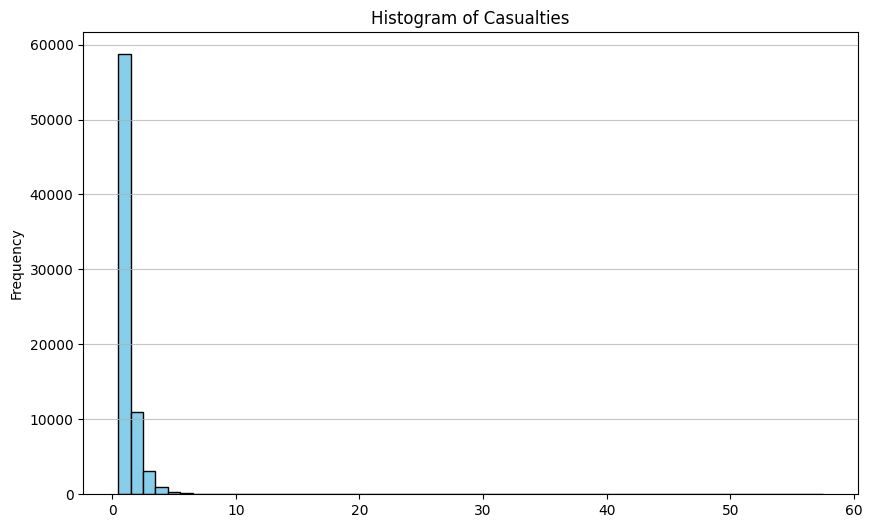

In [9]:
plt.figure(figsize=(10, 6))
plt.hist(df['Number_of_Casualties'], bins=np.arange(min(df['Number_of_Casualties']), max(df['Number_of_Casualties']) + 1, 1)-0.5, color='skyblue', edgecolor='black')
plt.title('Histogram of Casualties')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

As seen, casualty counts are concentrated around one injured individual per accident, with multi-casualty accidents being quite rare. This could also be why the variance is quite low.


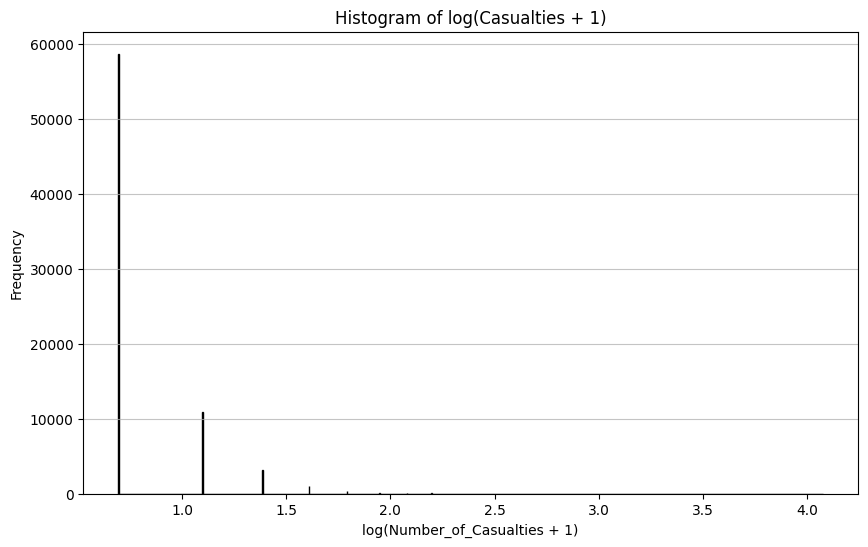

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(np.log(df['Number_of_Casualties'] + 1), bins=1000, color='skyblue', edgecolor='black')
plt.title('Histogram of log(Casualties + 1)')
plt.xlabel('log(Number_of_Casualties + 1)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

Applying log can reduce skewdness, stablise variance, and compressing the extreme values.

# Pre-processing

# Model: infastructure

We want to see how infastructural factors may influence number of casulty.

In [11]:
df_infastructure = df[['Number_of_Casualties','Junction_Control', 'Pedestrian_Crossing-Human_Control',
'Pedestrian_Crossing-Physical_Facilities',
'Light_Conditions',
'Special_Conditions_at_Site',
'Speed_limit']]

df_infastructure

,Number_of_Casualties,Junction_Control,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Special_Conditions_at_Site,Speed_limit
1,1,4,0,0,Darkness - lights lit,None,30.0
2,1,4,0,0,Darkness - lights lit,None,30.0
3,1,2,0,0,Daylight,None,30.0
5,1,4,0,8,Daylight,None,30.0
7,1,4,0,0,Daylight,None,30.0
...,...,...,...,...,...,...,...
128256,1,4,0,0,Daylight,None,40.0
128264,1,4,0,0,Darkness - no lighting,None,60.0
128269,1,4,0,0,Daylight,None,60.0
128271,1,4,0,0,Darkness - lights unlit,None,60.0


In [12]:
encoder = OneHotEncoder(sparse_output=False, dtype=int, drop='first')  # initialize encoder 
categorical_cols = ['Junction_Control', 'Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions', 'Special_Conditions_at_Site']
encoded_data = encoder.fit_transform(df_infastructure[categorical_cols])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_cols))
df_infastructure_encoded = pd.concat([df_infastructure.drop(columns=categorical_cols).reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)
df_infastructure_encoded

,Number_of_Casualties,Speed_limit,Junction_Control_2,Junction_Control_3,Junction_Control_4,Pedestrian_Crossing-Human_Control_1,Pedestrian_Crossing-Human_Control_2,Pedestrian_Crossing-Physical_Facilities_1,Pedestrian_Crossing-Physical_Facilities_4,Pedestrian_Crossing-Physical_Facilities_5,...,Light_Conditions_Darkness - lights unlit,Light_Conditions_Darkness - no lighting,Light_Conditions_Daylight,Special_Conditions_at_Site_Auto traffic signal - out,Special_Conditions_at_Site_Mud,Special_Conditions_at_Site_None,Special_Conditions_at_Site_Oil or diesel,Special_Conditions_at_Site_Road sign or marking defective or obscured,Special_Conditions_at_Site_Road surface defective,Special_Conditions_at_Site_Roadworks
0,1,30.0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,1,30.0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,1,30.0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0
3,1,30.0,0,0,1,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0
4,1,30.0,0,0,1,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74280,1,40.0,0,0,1,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0
74281,1,60.0,0,0,1,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
74282,1,60.0,0,0,1,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0
74283,1,60.0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0


In [13]:
X = df_infastructure_encoded.drop(columns=['Number_of_Casualties']) 

X_with_const = sm.add_constant(X)

# Define target variable
y = df_infastructure_encoded['Number_of_Casualties']

# Convert everything to float
X_with_const = X_with_const.astype(float)

# Fit the model
model_infastructure = sm.GLM(y, X_with_const, family=sm.families.Poisson()).fit()
print(model_infastructure.summary())

                  Generalized Linear Model Regression Results                   
Dep. Variable:     Number_of_Casualties   No. Observations:                74285
Model:                              GLM   Df Residuals:                    74262
Model Family:                   Poisson   Df Model:                           22
Link Function:                      Log   Scale:                          1.0000
Method:                            IRLS   Log-Likelihood:                -90791.
Date:                  Fri, 02 Oct 2026   Deviance:                       21084.
Time:                          03:09:35   Pearson chi2:                 3.15e+04
No. Iterations:                       5   Pseudo R-squ. (CS):           0.008830
Covariance Type:              nonrobust                                         
                                                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

Model fit is weak as the pseudo R² is 0.009, so these variables explain under 1% of the variation in casualties. Most of what determines casualties per accident is missing. This means that infastructure is not a good predictor for casualties.

As the data is underdispersed, the standard errors are too large, so some borderline results (like Pedestrian_Crossing-Human_Control_2, p = 0.077) may actually be significant.

## Applying Poisson GLM model

In [14]:
# Split data
X = df_infastructure_encoded.drop(columns=["Number_of_Casualties"])  # adjust target column name
y = df_infastructure_encoded["Number_of_Casualties"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Add constant (intercept)
X_train = sm.add_constant(X_train)
X_test  = sm.add_constant(X_test)

# Fit Poisson GLM
model_final = sm.GLM(y_train, X_train, family=sm.families.Poisson()).fit()

print(f"Model trained on {len(y_train)} observations")
print(f"Predictors: {X_train.columns.tolist()}")
print(f"Number of parameters: {len(model_final.params)}")

# Predictions
y_pred = model_final.predict(X_test)

# Metrics
rmse        = np.sqrt(mean_squared_error(y_test, y_pred))
r2          = r2_score(y_test, y_pred)
correlation = np.corrcoef(y_pred, y_test)[0, 1]
bias        = np.mean(y_pred - y_test.values)

# McFadden R² 
null_model  = sm.GLM(y_train, np.ones((len(y_train), 1)), family=sm.families.Poisson()).fit()
mcfadden_r2 = 1 - (model_final.llf / null_model.llf)

print("\nTEST SET PERFORMANCE")
print(f"RMSE:          {rmse:.4f}")
print(f"R²:            {r2:.4f}")
print(f"McFadden R²:   {mcfadden_r2:.4f}")
print(f"Correlation:   {correlation:.4f}")
print(f"Bias:          {bias:.4f}")

Model trained on 59428 observations
Predictors: ['const', 'Speed_limit', 'Junction_Control_2', 'Junction_Control_3', 'Junction_Control_4', 'Pedestrian_Crossing-Human_Control_1', 'Pedestrian_Crossing-Human_Control_2', 'Pedestrian_Crossing-Physical_Facilities_1', 'Pedestrian_Crossing-Physical_Facilities_4', 'Pedestrian_Crossing-Physical_Facilities_5', 'Pedestrian_Crossing-Physical_Facilities_7', 'Pedestrian_Crossing-Physical_Facilities_8', 'Light_Conditions_Darkness - lights lit', 'Light_Conditions_Darkness - lights unlit', 'Light_Conditions_Darkness - no lighting', 'Light_Conditions_Daylight', 'Special_Conditions_at_Site_Auto traffic signal - out', 'Special_Conditions_at_Site_Mud', 'Special_Conditions_at_Site_None', 'Special_Conditions_at_Site_Oil or diesel', 'Special_Conditions_at_Site_Road sign or marking defective or obscured', 'Special_Conditions_at_Site_Road surface defective', 'Special_Conditions_at_Site_Roadworks']
Number of parameters: 23

TEST SET PERFORMANCE
RMSE:          0.7

The predictions are off by ~0.73 casualties on average, which is a large error given that casualty counts are clustered at 1–3.
Given the R^2 the model explains only ~2% of the variance in casualties, which means it has almost no predictive power. This is supported by the McFadden R² for GLM as at 0.004,the model is null, meaning that the predictors are contributing almost nothing beyond the intercept.


There is also a very weak positive relationship between predicted and actual values.

Besides not having predictive power, the model isn't systematically over or underpredicting :')

# Coefficient Simulation

## Violin plot

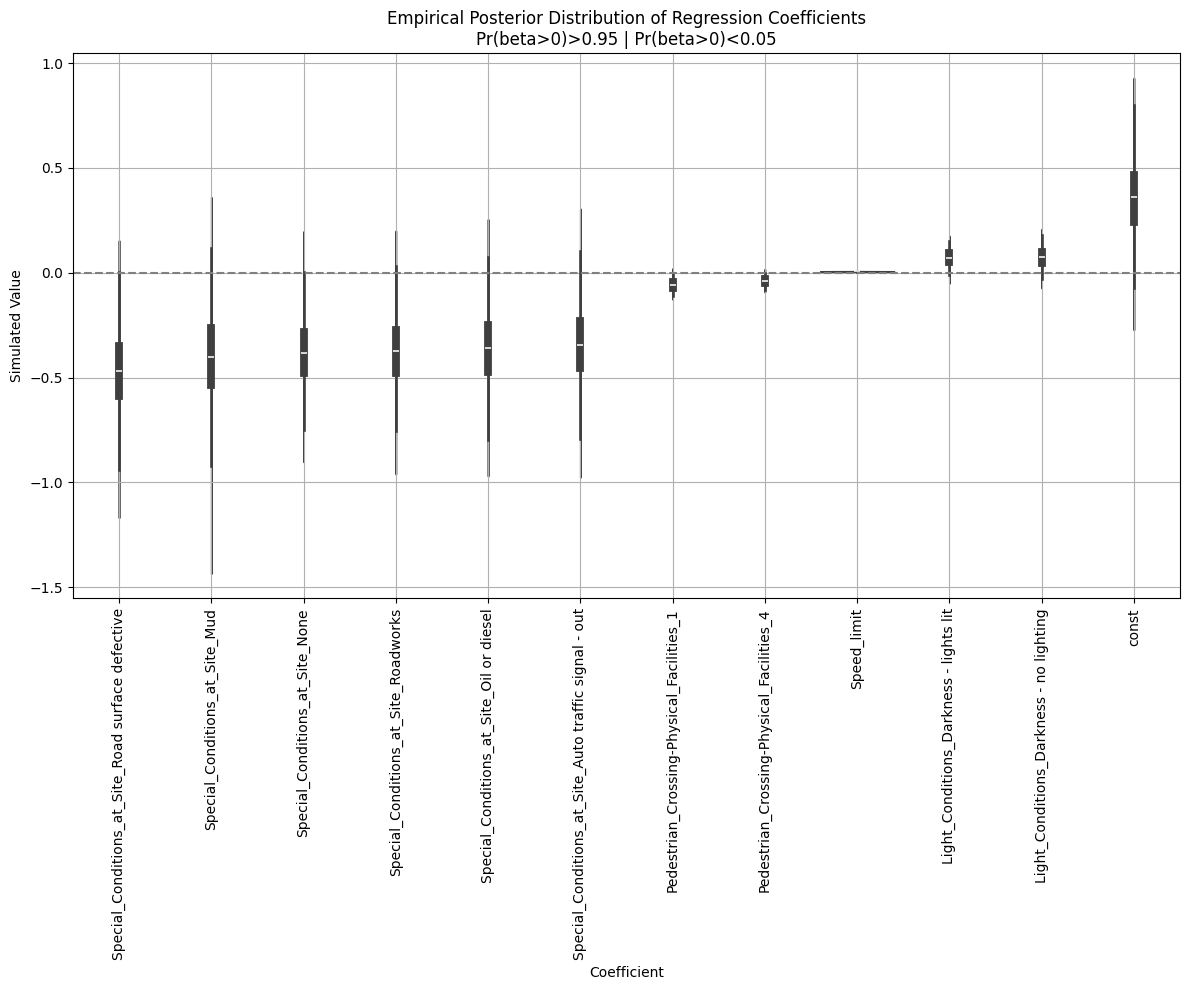

In [15]:
coefficients = model_final.params
cov_matrix = model_final.cov_params()

# Number of simulations
n_simulations = 1000

# Simulate beta coefficients
simulated_betas = multivariate_normal.rvs(mean=coefficients, cov=cov_matrix, size=n_simulations)

# Transform simulated_betas into a DataFrame for plotting
simulations_df = pd.DataFrame(simulated_betas, columns=model_final.params.index)

# Convert the DataFrame from wide to long format
long_df = simulations_df.melt(var_name='Coefficient', value_name='Value')

# Calculate the probability of coef > 0 for each coefficient
prob_greater_than_zero = long_df.groupby('Coefficient')['Value'].apply(lambda x: np.mean(x > 0)).reset_index()
prob_greater_than_zero.rename(columns={'Value': 'P(coef>0)'}, inplace=True)

# Filter coefficients based on the probability criterion
filtered_coefs = prob_greater_than_zero[
    (prob_greater_than_zero['P(coef>0)'] > 0.95) | (prob_greater_than_zero['P(coef>0)'] < 0.05)
]['Coefficient']

# Filter the long_df to include only the selected coefficients
filtered_long_df = long_df[long_df['Coefficient'].isin(filtered_coefs)]

# Calculate the median of the simulated values for each filtered coefficient
medians = filtered_long_df.groupby('Coefficient')['Value'].median().reset_index()

# Sort the filtered medians
medians_sorted = medians.sort_values(by='Value')


# Plotting the filtered and ordered coefficients
plt.figure(figsize=(12, 10))  # Adjust the figure size as needed
sns.violinplot(x='Coefficient', y='Value', data=filtered_long_df, order=medians_sorted['Coefficient'])

# Add a vertical dotted line at x = 0
plt.axhline(y=0, color='grey', linestyle='--')

# Additional customization
plt.title('Empirical Posterior Distribution of Regression Coefficients\nPr(beta>0)>0.95 | Pr(beta>0)<0.05')
plt.xticks(rotation=90)  # Rotate the x-axis labels for better readability
plt.xlabel('Coefficient')
plt.ylabel('Simulated Value')
plt.grid(True)

# Display the plot
plt.tight_layout()  # Adjust layout to not cut off labels
plt.show()

The plot displays the simulated distributions of statistically credible regression coefficients from a Poisson GLM, filtered to those where the probability of the coefficient being positive exceeds 95%, or falls below 5%, meaning only predictors with a consistent directional effect are shown.

Most Special_Conditions_at_Site dummies, including Mud, None, Roadworks, Oil/diesel, Road surface defective, and Auto traffic signal out, show negative coefficients clustered around -0.4 to -0.5. This means that these conditions are all associated with fewer predicted casualties compared to the reference (baseline) category. The negative coefficient of this may be because the condition was dropped during one-hot encoding appears to be associated with higher casualty counts than any of the named conditions. The wide whiskers on Mud and None indicate these are rare in the data, making their estimates uncertain.

Pedestrian_Crossing-Physical_Facilities_1 and _4 show small negative effects close to zero. These likely represent crossing infrastructure that offers some modest protective effect on casualty counts, though the effect size is small.

DeSpeed_limit sits very close to zero. This suggests that once other infrastructure variables are controlled for, the posted speed limit alone contributes little marginal predictive power 


Lighting show small positive coefficients, meaning accidents in darker conditions are associated with slightly more casualties compared to the baseline lighting condition.


The model captures some expected directional relationships, likedarkness increasing casualties and certain crossing infrastructure reducing them, but the dominance of the Special Conditions variables and the near-zero effect of speed limit suggest the feature set has limited explanatory power for casualty counts, consistent with the low R^2 observed in model evaluation.

# Model Evaluation

In [16]:
# Generate predictions for each simulation
predicted_counts = np.zeros((n_simulations, X_with_const.shape[0]))

for i in range(n_simulations):
    beta_simulation = simulated_betas[i]
    predicted_rate = np.exp(np.dot(X_with_const, beta_simulation))
    predicted_counts[i] = np.random.poisson(predicted_rate)

In [17]:

monte_carlo_medians = np.median(predicted_counts, axis=0)   # np.median(...)
prediction_intervals = np.percentile(predicted_counts, [2.5, 97.5], axis=0)  # np.percentile(...)

# Calculate metrics
correlation = np.corrcoef(monte_carlo_medians, y)[0, 1]
rmse = np.sqrt(np.mean((monte_carlo_medians - y)**2))
bias = np.mean(monte_carlo_medians - y)          # np.mean(...)  # Mean prediction error
coverage = np.mean((prediction_intervals[0] <= y) & (y <= prediction_intervals[1]))  


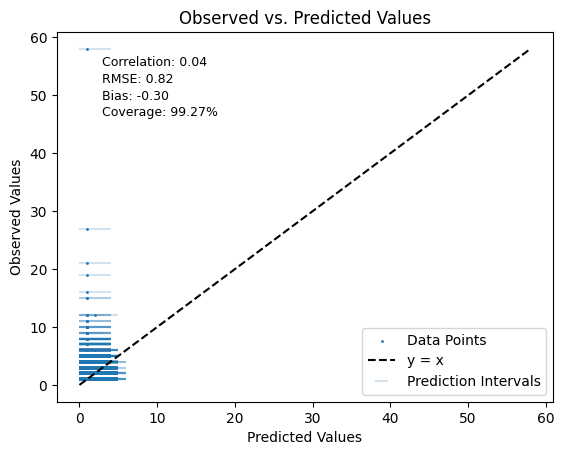

In [18]:
# Flatten predicted_samples to make it 1-dimensional
predicted_counts_flat = predicted_counts.flatten()

# Concatenate the flattened predicted_samples with y
combined_array = np.concatenate([predicted_counts_flat, y])

# calculate min and max
min_val = combined_array.min()
max_val = combined_array.max()

# Plotting
scatter = plt.scatter(monte_carlo_medians, y, s=1, alpha=1, label='Data Points')
errorbar = plt.errorbar(monte_carlo_medians, y, xerr=np.abs(prediction_intervals - monte_carlo_medians), fmt='none', alpha=0.2, label='Prediction Intervals')
y_equals_x = plt.plot([min_val, max_val], [min_val, max_val], 'k--', zorder=3, label='y = x')

# Add legend with metrics
legend_labels = [
    f'Correlation: {correlation:.2f}',
    f'RMSE: {rmse:.2f}',
    f'Bias: {bias:.2f}',
    f'Coverage: {coverage:.2%}'
]

# Add legend for plot elements
plt.legend(loc='lower right')

# Text annotations for metrics
text_x = min_val + (max_val - min_val) * 0.05  # Adjust these positions as necessary
text_y_start = max_val - (max_val - min_val) * 0.05  # Starting y position for text
line_height = (max_val - min_val) * 0.05  # Adjust line height as necessary

for i, label in enumerate(legend_labels):
    plt.text(text_x, text_y_start - i * line_height, label, fontsize=9)

plt.title('Observed vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Observed Values')
plt.show()


This plot confirms and visualises the predicted and observed value, where the closer to the y=x line the better the prediction. As almost everything is clustered in the bottom-left corner, with predicted values stuck between 0–5 while observed values range up to 58. The model is severely underpredicting high-casualty events.

The prediction intervals are also extremely wide, which is why coverage is 99.27%. However, this means that the model is overconfident as the intervals are so wide they catch almost everything, but the point predictions are still poor. 

The model has learned roughly that most accidents involve 1–2 casualties and predicts that for almost every case. It completely fails to capture higher casualty accidents.